🫀 HEART SOUND CLASSIFIER - PREDICTION TOOL
✅ Model loaded successfully!
   Model type: RandomForestClassifier
   Classes: ['Normal', 'RHD']

📁 Testing on sample files...

🎵 Found 4 test files

File: 49631.wav
Prediction: Normal (95.2%)
  Normal: 95.23%
  RHD: 4.77%

📊 Generating visualization...
✅ Visualization saved to: ../models/mitral_classifier_v4/sample_prediction.png


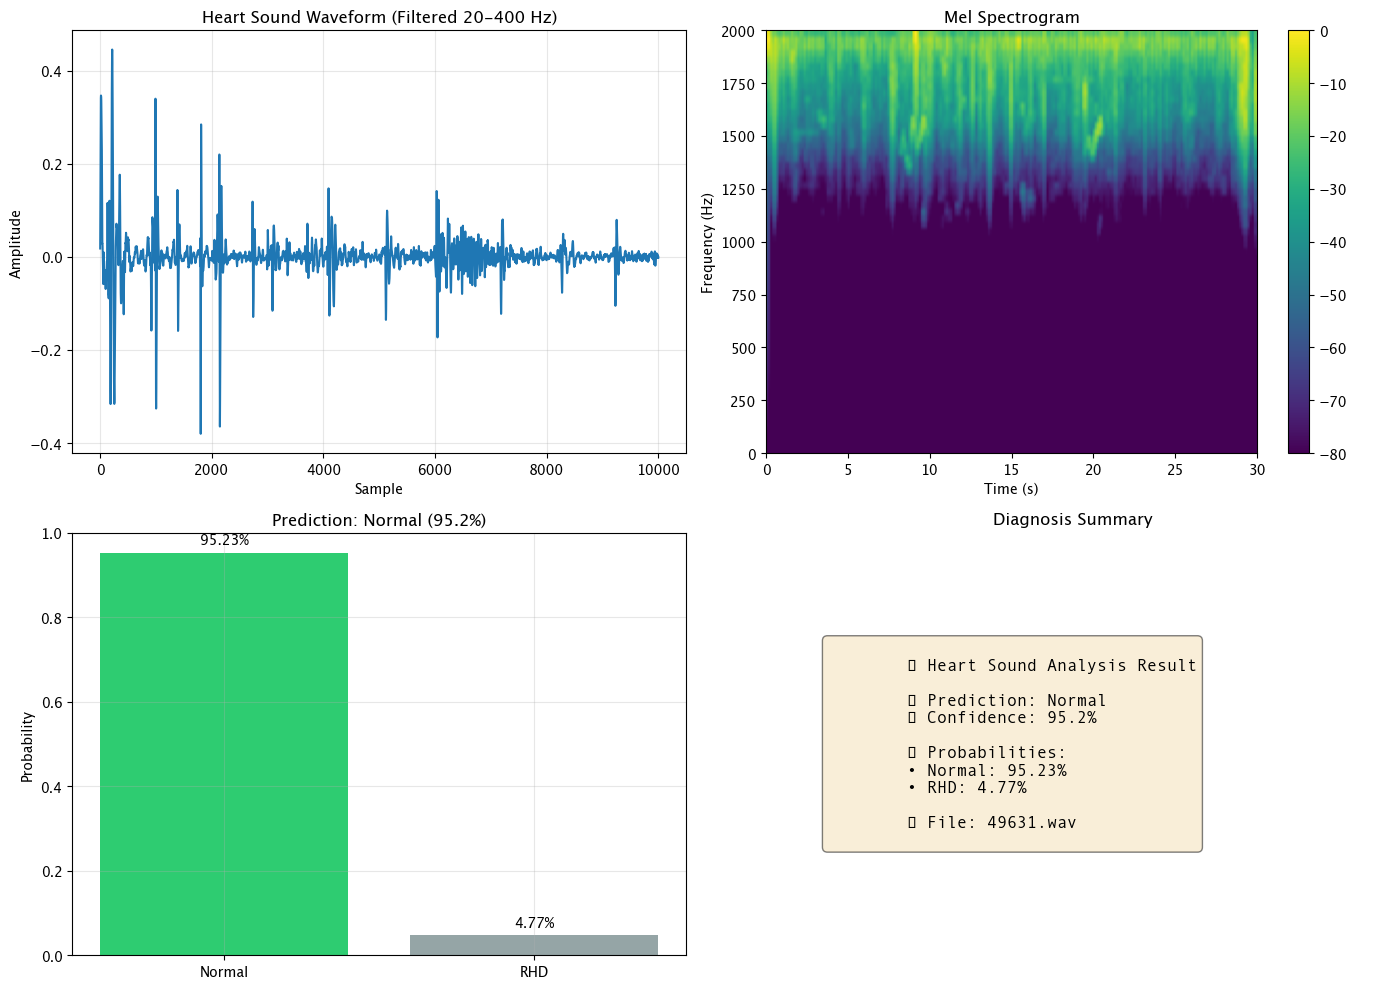


🔍 PREDICTION EXPLANATION
Prediction: Normal (95.2%)
File: 49631.wav

Top 10 Most Important Features:
--------------------------------------------------
  env_mean            : 0.0645 (value: 0.0150)
  zcr_std             : 0.0568 (value: 0.0258)
  env_peak_ratio      : 0.0491 (value: 18.7723)
  std                 : 0.0365 (value: 0.0320)
  rms                 : 0.0348 (value: 0.0320)
  band_2_power        : 0.0304 (value: 0.0814)
  env_std             : 0.0277 (value: 0.0214)
  mfcc_7_std          : 0.0269 (value: 7.8703)
  mfcc_5              : 0.0256 (value: -13.7201)
  mfcc_12_std         : 0.0253 (value: 4.2046)

File: 84864.wav
Prediction: Normal (61.4%)
  Normal: 61.39%
  RHD: 38.61%

File: 85207.wav
Prediction: RHD (70.1%)
  Normal: 29.93%
  RHD: 70.07%

File: 85165.wav
Prediction: RHD (97.0%)
  Normal: 2.99%
  RHD: 97.01%

💡 Quick Start Guide:
1. Predict a single file:
   result = predictor.predict_single('path/to/audio.wav')
   print(result)

2. Predict and visualize:
   pre

In [4]:
# prediction.ipynb - Heart Sound Classifier Prediction
import os
import numpy as np
import pandas as pd
import librosa
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configuration
MODEL_PATH = '../models/mitral_classifier_v4'
BALANCED_PATH = '../data/balanced/mitral_valve'

class HeartSoundPredictor:
    """Heart sound classifier using the trained Random Forest model"""
    
    def __init__(self, model_path=MODEL_PATH):
        """Load the trained model and scaler"""
        self.model = joblib.load(os.path.join(model_path, 'best_model.pkl'))
        self.scaler = joblib.load(os.path.join(model_path, 'scaler.pkl'))
        self.classes = ['Normal', 'RHD']
        
        # Feature extractor parameters
        self.sr = 4000
        
        print("✅ Model loaded successfully!")
        print(f"   Model type: {type(self.model).__name__}")
        print(f"   Classes: {self.classes}")
        
    def extract_features(self, file_path):
        """Extract features from audio file (same as training)"""
        try:
            # Load audio
            signal, _ = librosa.load(file_path, sr=self.sr, duration=10.0)
            
            if len(signal) < 1000:
                return None
            
            features = {}
            
            # 1. Basic statistics
            features['mean'] = np.mean(signal)
            features['std'] = np.std(signal)
            features['rms'] = np.sqrt(np.mean(signal**2))
            features['peak'] = np.max(np.abs(signal))
            
            # 2. Zero crossing rate
            zcr = librosa.feature.zero_crossing_rate(signal)[0]
            features['zcr_mean'] = np.mean(zcr)
            features['zcr_std'] = np.std(zcr)
            
            # 3. Spectral features
            try:
                spec = np.abs(librosa.stft(signal, n_fft=1024, hop_length=256))
                spec_db = librosa.amplitude_to_db(spec, ref=np.max)
                
                features['spec_mean'] = np.mean(spec_db)
                features['spec_std'] = np.std(spec_db)
                features['spec_max'] = np.max(spec_db)
                
                freqs = librosa.fft_frequencies(sr=self.sr, n_fft=1024)
                centroid = np.sum(freqs[:, None] * spec, axis=0) / (np.sum(spec, axis=0) + 1e-8)
                features['spec_centroid'] = np.mean(centroid)
                features['spec_centroid_std'] = np.std(centroid)
                
                bandwidth = np.sqrt(np.sum((freqs[:, None] - centroid[None, :])**2 * spec, axis=0) / (np.sum(spec, axis=0) + 1e-8))
                features['spec_bandwidth'] = np.mean(bandwidth)
                
                cumsum = np.cumsum(spec, axis=0)
                rolloff = np.argmax(cumsum >= 0.85 * cumsum[-1, :], axis=0)
                features['spec_rolloff'] = np.mean(rolloff) * self.sr / 1024
            except:
                features['spec_mean'] = 0
                features['spec_std'] = 0
                features['spec_max'] = 0
                features['spec_centroid'] = 0
                features['spec_centroid_std'] = 0
                features['spec_bandwidth'] = 0
                features['spec_rolloff'] = 0
            
            # 4. MFCC features
            try:
                mfccs = librosa.feature.mfcc(y=signal, sr=self.sr, n_mfcc=13, n_fft=1024)
                for i in range(13):
                    features[f'mfcc_{i}'] = np.mean(mfccs[i])
                    features[f'mfcc_{i}_std'] = np.std(mfccs[i])
            except:
                for i in range(13):
                    features[f'mfcc_{i}'] = 0
                    features[f'mfcc_{i}_std'] = 0
            
            # 5. Mel spectrogram summary
            try:
                mel_spec = librosa.feature.melspectrogram(y=signal, sr=self.sr, n_mels=64, n_fft=1024)
                mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
                features['mel_mean'] = np.mean(mel_spec_db)
                features['mel_std'] = np.std(mel_spec_db)
                features['mel_max'] = np.max(mel_spec_db)
                features['mel_energy'] = np.sum(mel_spec_db)
            except:
                features['mel_mean'] = 0
                features['mel_std'] = 0
                features['mel_max'] = 0
                features['mel_energy'] = 0
            
            # 6. Tempo
            try:
                tempo, _ = librosa.beat.beat_track(y=signal, sr=self.sr)
                features['tempo'] = float(tempo) if isinstance(tempo, np.ndarray) else tempo
            except:
                features['tempo'] = 0
            
            # 7. Envelope features
            envelope = np.abs(signal)
            envelope_smooth = np.convolve(envelope, np.ones(50)/50, mode='same')
            features['env_mean'] = np.mean(envelope_smooth)
            features['env_std'] = np.std(envelope_smooth)
            features['env_peak'] = np.max(envelope_smooth)
            features['env_peak_ratio'] = features['env_peak'] / (features['env_mean'] + 1e-8)
            
            # 8. Frequency band power ratios
            try:
                fft = np.fft.rfft(signal)
                freqs = np.fft.rfftfreq(len(signal), 1/self.sr)
                power = np.abs(fft)**2
                
                bands = [(20, 80), (80, 200), (200, 400)]
                total_power = np.sum(power) + 1e-8
                
                for i, (low, high) in enumerate(bands):
                    mask = (freqs >= low) & (freqs < high)
                    features[f'band_{i}_power'] = np.sum(power[mask]) / total_power
            except:
                for i in range(3):
                    features[f'band_{i}_power'] = 0
            
            return features
            
        except Exception as e:
            print(f"Error extracting features: {e}")
            return None
    
    def predict_single(self, audio_path, return_all=False):
        """Predict class for a single audio file"""
        # Extract features
        features = self.extract_features(audio_path)
        
        if features is None:
            return None
        
        # Convert to DataFrame
        feature_df = pd.DataFrame([features])
        feature_df = feature_df.fillna(0)
        
        # Scale features
        X_scaled = self.scaler.transform(feature_df)
        
        # Predict
        prediction = self.model.predict(X_scaled)[0]
        probability = self.model.predict_proba(X_scaled)[0]
        
        predicted_class = self.classes[prediction]
        confidence = probability[prediction] * 100
        
        if return_all:
            return {
                'class': predicted_class,
                'confidence': confidence,
                'prob_normal': probability[0],
                'prob_rhd': probability[1],
                'features': features
            }
        else:
            return predicted_class
    
    def predict_batch(self, audio_paths, verbose=True):
        """Predict classes for multiple audio files"""
        results = []
        
        for i, path in enumerate(audio_paths):
            if verbose and i % 10 == 0:
                print(f"Processing {i+1}/{len(audio_paths)}...")
            
            result = self.predict_single(path, return_all=True)
            if result:
                result['file'] = path
                results.append(result)
        
        return pd.DataFrame(results)
    
    def visualize_prediction(self, audio_path, save_path=None):
        """Visualize the audio and prediction"""
        result = self.predict_single(audio_path, return_all=True)
        
        if result is None:
            print("Error: Could not process audio file")
            return
        
        # Load audio for visualization
        signal, sr = librosa.load(audio_path, sr=self.sr)
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # 1. Waveform
        axes[0, 0].plot(signal[:min(len(signal), 10000)])
        axes[0, 0].set_title('Heart Sound Waveform (Filtered 20-400 Hz)', fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('Sample')
        axes[0, 0].set_ylabel('Amplitude')
        axes[0, 0].grid(True, alpha=0.3)
        
        # 2. Mel Spectrogram
        mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=64)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        im = axes[0, 1].imshow(mel_spec_db, aspect='auto', 
                              extent=[0, len(signal)/sr, 0, sr/2])
        axes[0, 1].set_title('Mel Spectrogram', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Time (s)')
        axes[0, 1].set_ylabel('Frequency (Hz)')
        plt.colorbar(im, ax=axes[0, 1])
        
        # 3. Prediction probabilities
        probs = [result['prob_normal'], result['prob_rhd']]
        colors = ['#2ecc71' if result['class'] == 'Normal' else '#95a5a6',
                 '#e74c3c' if result['class'] == 'RHD' else '#95a5a6']
        bars = axes[1, 0].bar(['Normal', 'RHD'], probs, color=colors)
        axes[1, 0].set_title(f"Prediction: {result['class']} ({result['confidence']:.1f}%)", 
                           fontsize=12, fontweight='bold')
        axes[1, 0].set_ylabel('Probability')
        axes[1, 0].set_ylim([0, 1])
        axes[1, 0].grid(True, alpha=0.3)
        for i, v in enumerate(probs):
            axes[1, 0].text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold')
        
        # 4. Summary
        axes[1, 1].axis('off')
        summary_text = f"""
        🏥 Heart Sound Analysis Result
        
        📊 Prediction: {result['class']}
        🎯 Confidence: {result['confidence']:.1f}%
        
        📈 Probabilities:
        • Normal: {result['prob_normal']:.2%}
        • RHD: {result['prob_rhd']:.2%}
        
        📁 File: {os.path.basename(audio_path)}
        """
        axes[1, 1].text(0.1, 0.5, summary_text, 
                       transform=axes[1, 1].transAxes,
                       fontsize=12, verticalalignment='center',
                       fontfamily='monospace',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        axes[1, 1].set_title('Diagnosis Summary', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"✅ Visualization saved to: {save_path}")
        
        plt.show()
        return result
    
    def explain_prediction(self, audio_path):
        """Explain the prediction with feature importance"""
        result = self.predict_single(audio_path, return_all=True)
        
        if result is None:
            return
        
        # Get feature importance
        if hasattr(self.model, 'feature_importances_'):
            # Get feature names
            feature_df = pd.DataFrame([result['features']])
            feature_df = feature_df.fillna(0)
            feature_names = feature_df.columns
            
            # Get top important features
            importances = self.model.feature_importances_
            feature_importance = pd.DataFrame({
                'Feature': feature_names,
                'Importance': importances
            }).sort_values('Importance', ascending=False)
            
            # Get top 10 features
            top_features = feature_importance.head(10)
            
            print("\n" + "="*60)
            print("🔍 PREDICTION EXPLANATION")
            print("="*60)
            print(f"Prediction: {result['class']} ({result['confidence']:.1f}%)")
            print(f"File: {os.path.basename(audio_path)}")
            print("\nTop 10 Most Important Features:")
            print("-"*50)
            
            for idx, row in top_features.iterrows():
                feature_name = row['Feature']
                importance = row['Importance']
                value = result['features'].get(feature_name, 0)
                print(f"  {feature_name:20s}: {importance:.4f} (value: {value:.4f})")
            
            return top_features
        else:
            print("Feature importance not available for this model type")

# Example Usage
if __name__ == "__main__":
    print("="*60)
    print("🫀 HEART SOUND CLASSIFIER - PREDICTION TOOL")
    print("="*60)
    
    # Initialize predictor
    predictor = HeartSoundPredictor()
    
    # Test on a sample file
    print("\n📁 Testing on sample files...")
    
    # Try to find some test files
    test_files = []
    for label in ['normal', 'rhd']:
        label_path = os.path.join(BALANCED_PATH, label)
        if os.path.exists(label_path):
            files = [os.path.join(label_path, f) for f in os.listdir(label_path) 
                    if f.endswith('.wav')][:2]
            test_files.extend(files)
    
    if test_files:
        print(f"\n🎵 Found {len(test_files)} test files")
        
        for file_path in test_files:
            print("\n" + "="*50)
            result = predictor.predict_single(file_path, return_all=True)
            print(f"File: {os.path.basename(file_path)}")
            print(f"Prediction: {result['class']} ({result['confidence']:.1f}%)")
            print(f"  Normal: {result['prob_normal']:.2%}")
            print(f"  RHD: {result['prob_rhd']:.2%}")
            
            # Visualize the first file
            if file_path == test_files[0]:
                print("\n📊 Generating visualization...")
                predictor.visualize_prediction(file_path, 
                                             save_path='../models/mitral_classifier_v4/sample_prediction.png')
                
                # Show feature importance
                predictor.explain_prediction(file_path)
    else:
        print("⚠️ No test files found. Please check the data path.")
    
    print("\n" + "="*60)
    print("💡 Quick Start Guide:")
    print("="*60)
    print("1. Predict a single file:")
    print("   result = predictor.predict_single('path/to/audio.wav')")
    print("   print(result)")
    print()
    print("2. Predict and visualize:")
    print("   predictor.visualize_prediction('path/to/audio.wav')")
    print()
    print("3. Predict multiple files:")
    print("   results = predictor.predict_batch(['file1.wav', 'file2.wav'])")
    print()
    print("4. Explain prediction (feature importance):")
    print("   predictor.explain_prediction('path/to/audio.wav')")